# Sensitivity Checks for Frozen Methodological Choices

This notebook collects the sensitivity evidence behind the parameters reported in the methodology section. It is organized in the same order as the paper narrative:

1. Graph construction choices: session threshold, behavioral window/support, and acoustic kNN/similarity threshold.
2. Community detection and representation-learning choices: Louvain/Leiden resolution, Node2Vec walk bias and cluster count, and GAE hyperparameters and cluster count.
3. Genre inference choices: representation family comparison and Logistic Regression regularization selection.

The goal is compact inspection rather than exhaustive diagnostics. Each panel emphasizes the metric that was actually used to freeze the parameter, plus one or two structural sanity checks when relevant.

In [1]:
from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

CANDIDATE_ROOTS = [
    Path.cwd(),
    Path.cwd() / "music-graphs",
    Path("/data/manuel/music-graphs"),
]
ROOT = next(path for path in CANDIDATE_ROOTS if (path / "configs").exists())
FIGURES_DIR = ROOT / "reports" / "figures" / "sensitivity_freeze_overview"
TABLES_DIR = ROOT / "reports" / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 240,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "semibold",
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.frameon": False,
})

PALETTE = {
    "Behavioral": "#3B82B8",
    "Acoustic": "#D05A6E",
    "Leiden": "#2A9D8F",
    "Louvain": "#E9A441",
    "Node2Vec": "#6D5BD0",
    "GAE": "#BE5A38",
}

FROZEN = {
    "session_threshold_minutes": 60,
    "behavioral_window_size": 5,
    "minimum_shared_sessions": 2,
    "acoustic_nearest_neighbors": 20,
    "acoustic_min_similarity": 0.40,
    "modularity_resolution": 2.25,
    "node2vec_behavioral": {"p": 2.0, "q": 1.0, "k": 54},
    "node2vec_acoustic": {"p": 2.0, "q": 2.0, "k": 54},
    "kmeans_k": 54,
    "genre_c_grid": [0.01, 0.1, 1.0, 10.0, 100.0],
}


def read_csv(rel_path, required=False):
    path = ROOT / rel_path
    if not path.exists():
        message = f"Missing {'required' if required else 'optional'} CSV: {rel_path}"
        if required:
            raise FileNotFoundError(message)
        print(message)
        return pd.DataFrame()
    return pd.read_csv(path)


def read_json(rel_path, required=False):
    path = ROOT / rel_path
    if not path.exists():
        message = f"Missing {'required' if required else 'optional'} JSON: {rel_path}"
        if required:
            raise FileNotFoundError(message)
        print(message)
        return {}
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def savefig(fig, name):
    path = FIGURES_DIR / name
    fig.savefig(path, bbox_inches="tight")
    print(f"Saved: {path.relative_to(ROOT)}")


def selected_vline(ax, value, label="selected"):
    ax.axvline(value, color="#222222", linestyle="--", linewidth=1.1, alpha=0.75)
    ymax = ax.get_ylim()[1]
    ax.text(value, ymax, f" {label}={value}", va="top", ha="left", fontsize=8, color="#222222")


def selected_hline(ax, value, label="selected"):
    ax.axhline(value, color="#222222", linestyle="--", linewidth=1.1, alpha=0.75)
    xmax = ax.get_xlim()[1]
    ax.text(xmax, value, f" {label}={value}", va="bottom", ha="right", fontsize=8, color="#222222")


def line_with_points(ax, data, x, y, color, label=None, marker="o"):
    data = data.sort_values(x)
    ax.plot(data[x], data[y], marker=marker, linewidth=2.0, color=color, label=label)


def format_count_axis(ax):
    ax.ticklabel_format(axis="y", style="plain")
    ax.grid(axis="y", alpha=0.25)


def add_value_labels(ax, fmt="{:.3f}", fontsize=8):
    for patch in ax.patches:
        width = patch.get_width()
        if np.isfinite(width):
            ax.text(width, patch.get_y() + patch.get_height() / 2, "  " + fmt.format(width), va="center", fontsize=fontsize)


def heatmap(ax, data, row, col, value, title, cmap="viridis", annotate=True, fmt=".2f"):
    pivot = data.pivot_table(index=row, columns=col, values=value, aggfunc="mean").sort_index().sort_index(axis=1)
    arr = pivot.to_numpy(dtype=float)
    im = ax.imshow(arr, aspect="auto", cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel(col.replace("_", " "))
    ax.set_ylabel(row.replace("_", " "))
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels([str(x) for x in pivot.columns])
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels([str(x) for x in pivot.index])
    if annotate:
        for i in range(arr.shape[0]):
            for j in range(arr.shape[1]):
                if np.isfinite(arr[i, j]):
                    ax.text(j, i, format(arr[i, j], fmt), ha="center", va="center", color="white", fontsize=8)
    return im, pivot


def mark_heatmap_choice(ax, pivot, selected_row, selected_col):
    if selected_row in pivot.index and selected_col in pivot.columns:
        y = list(pivot.index).index(selected_row)
        x = list(pivot.columns).index(selected_col)
        ax.scatter([x], [y], marker="s", s=150, facecolors="none", edgecolors="#111111", linewidths=2.0)


def method_graph_family(name):
    text = str(name).lower()
    if "acoustic" in text:
        return "Acoustic"
    return "Behavioral"

print(f"Repository root: {ROOT}")
print(f"Figures will be written to: {FIGURES_DIR.relative_to(ROOT)}")

Repository root: /data/manuel/music-graphs
Figures will be written to: reports/figures/sensitivity_freeze_overview


## 0. Frozen Choices Readout

This table is a quick sanity check that the notebook is aligned with the current pipeline configuration and methodological notes.

In [2]:
decision_tables = []
for rel in [
    "reports/tables/table_hyperparameter_decisions.csv",
    "reports/tables/table_algorithm_hyperparameter_decision_readout.csv",
]:
    df = read_csv(rel)
    if not df.empty:
        df.insert(0, "source_table", Path(rel).name)
        decision_tables.append(df)

if decision_tables:
    decisions = pd.concat(decision_tables, ignore_index=True, sort=False)
    display(decisions)
else:
    display(Markdown("No decision tables were found yet."))

,source_table,decision,selected,selection_rule,uses_external_genres,family,graph,selection_axis
0,table_hyperparameter_decisions.csv,session_threshold_minutes,60,closest tested threshold to p95 inter-scrobble...,False,NaN,NaN,NaN
1,table_hyperparameter_decisions.csv,behavioral_relation_mode,sequential_k5,bounded local context; limits long-session eff...,False,NaN,NaN,NaN
2,table_hyperparameter_decisions.csv,minimum_shared_sessions,2,repeated evidence while retaining a broad domi...,False,NaN,NaN,NaN
3,table_hyperparameter_decisions.csv,behavioral_edge_weight,shared_session_cosine,normalize repeated evidence and reduce activit...,False,NaN,NaN,NaN
4,table_hyperparameter_decisions.csv,minimum_artist_scrobbles,3,exclude extremely sparse activity,False,NaN,NaN,NaN
5,table_hyperparameter_decisions.csv,modularity_balanced_resolution,2.25,frozen exploratory trade-off; reported transpa...,True,NaN,NaN,NaN
6,table_hyperparameter_decisions.csv,node2vec_balanced_k,54,match balanced structural-community scale,False,NaN,NaN,NaN
7,table_hyperparameter_decisions.csv,node2vec_walk_bias,"p=2.0, q=1.0",maximum mean silhouette across five seeds,False,NaN,NaN,NaN
8,table_algorithm_hyperparameter_decision_readou...,NaN,resolution=2.25,balanced structural scale retained for both gr...,NaN,Louvain/Leiden,Behavioral + Acoustic,resolution
9,table_algorithm_hyperparameter_decision_readou...,NaN,"p=2.0, q=1.0",maximum mean silhouette across seeds,NaN,Node2Vec,Behavioral,p/q at k=54


## 1. Graph Construction Sensitivity

The construction parameters were frozen before the downstream supervised benchmark. The behavioral graph uses sequential listening proximity, while the acoustic graph uses standardized AcousticBrainz feature vectors and kNN sparsification.

In [3]:
session = read_csv("results/session_audit/session_threshold_sensitivity.csv")
behavior_support = read_csv("data/interim/listening_graphs/sequential_k5/min_shared_sessions_sensitivity.csv")
acoustic_sensitivity = read_csv("data/processed/acoustic_graphs/top10_knn20_min0_40/graph_acoustic_knn_threshold_sensitivity.csv")

behavior_k_rows = []
for summary_path in sorted((ROOT / "data/interim/listening_graphs").glob("sequential_k*/graph_edges_summary.json")):
    match = re.search(r"sequential_k(\d+)", str(summary_path))
    if not match:
        continue
    window_size = int(match.group(1))
    with summary_path.open("r", encoding="utf-8") as handle:
        summary = json.load(handle)
    row = {
        "window_size_scrobbles": window_size,
        "candidate_pair_count": summary.get("candidate_pair_count_before_self_loop_removal"),
        "raw_unique_edge_count": summary.get("raw_unique_edge_count"),
    }
    support_path = summary_path.parent / "min_shared_sessions_sensitivity.csv"
    if support_path.exists():
        support_df = pd.read_csv(support_path)
        selected = support_df.loc[
            support_df["min_shared_sessions"].eq(FROZEN["minimum_shared_sessions"])
        ]
        if not selected.empty:
            for col in [
                "edge_count",
                "node_count_with_edges",
                "isolated_node_count",
                "largest_component_node_count",
                "largest_component_percentage_of_active_nodes",
                "mean_degree_active_nodes",
                "median_multi_user_decayed_shared_session_cosine",
            ]:
                row[col] = selected.iloc[0].get(col)
    behavior_k_rows.append(row)

behavior_window = pd.DataFrame(behavior_k_rows).sort_values("window_size_scrobbles")

print("Behavioral window sensitivity rows:", len(behavior_window))
print("Acoustic kNN/threshold grid rows:", len(acoustic_sensitivity))

Behavioral window sensitivity rows: 5
Acoustic kNN/threshold grid rows: 24


Saved: reports/figures/sensitivity_freeze_overview/fig_01_session_threshold_sensitivity.png


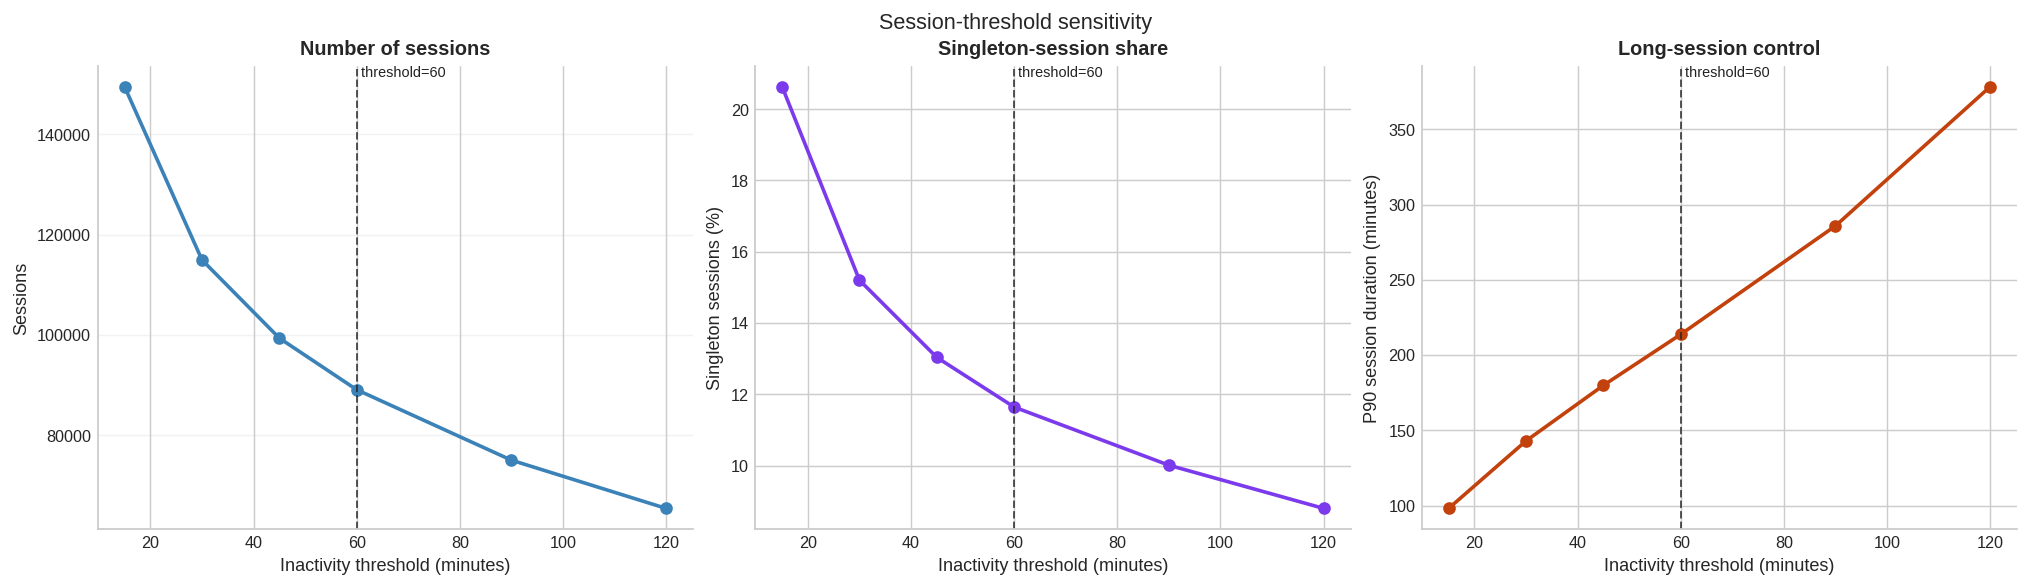

In [4]:
if not session.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.2), constrained_layout=True)

    line_with_points(axes[0], session, "threshold_minutes", "session_count", PALETTE["Behavioral"])
    selected_vline(axes[0], FROZEN["session_threshold_minutes"], "threshold")
    axes[0].set_title("Number of sessions")
    axes[0].set_xlabel("Inactivity threshold (minutes)")
    axes[0].set_ylabel("Sessions")
    format_count_axis(axes[0])

    line_with_points(axes[1], session, "threshold_minutes", "singleton_session_percentage", "#7C3AED")
    selected_vline(axes[1], FROZEN["session_threshold_minutes"], "threshold")
    axes[1].set_title("Singleton-session share")
    axes[1].set_xlabel("Inactivity threshold (minutes)")
    axes[1].set_ylabel("Singleton sessions (%)")

    line_with_points(axes[2], session, "threshold_minutes", "p90_session_duration_minutes", "#C2410C")
    selected_vline(axes[2], FROZEN["session_threshold_minutes"], "threshold")
    axes[2].set_title("Long-session control")
    axes[2].set_xlabel("Inactivity threshold (minutes)")
    axes[2].set_ylabel("P90 session duration (minutes)")

    fig.suptitle("Session-threshold sensitivity", y=1.04)
    savefig(fig, "fig_01_session_threshold_sensitivity.png")
    plt.show()
else:
    display(Markdown("Session-threshold sensitivity table is missing."))

Saved: reports/figures/sensitivity_freeze_overview/fig_02_behavioral_graph_construction_sensitivity.png


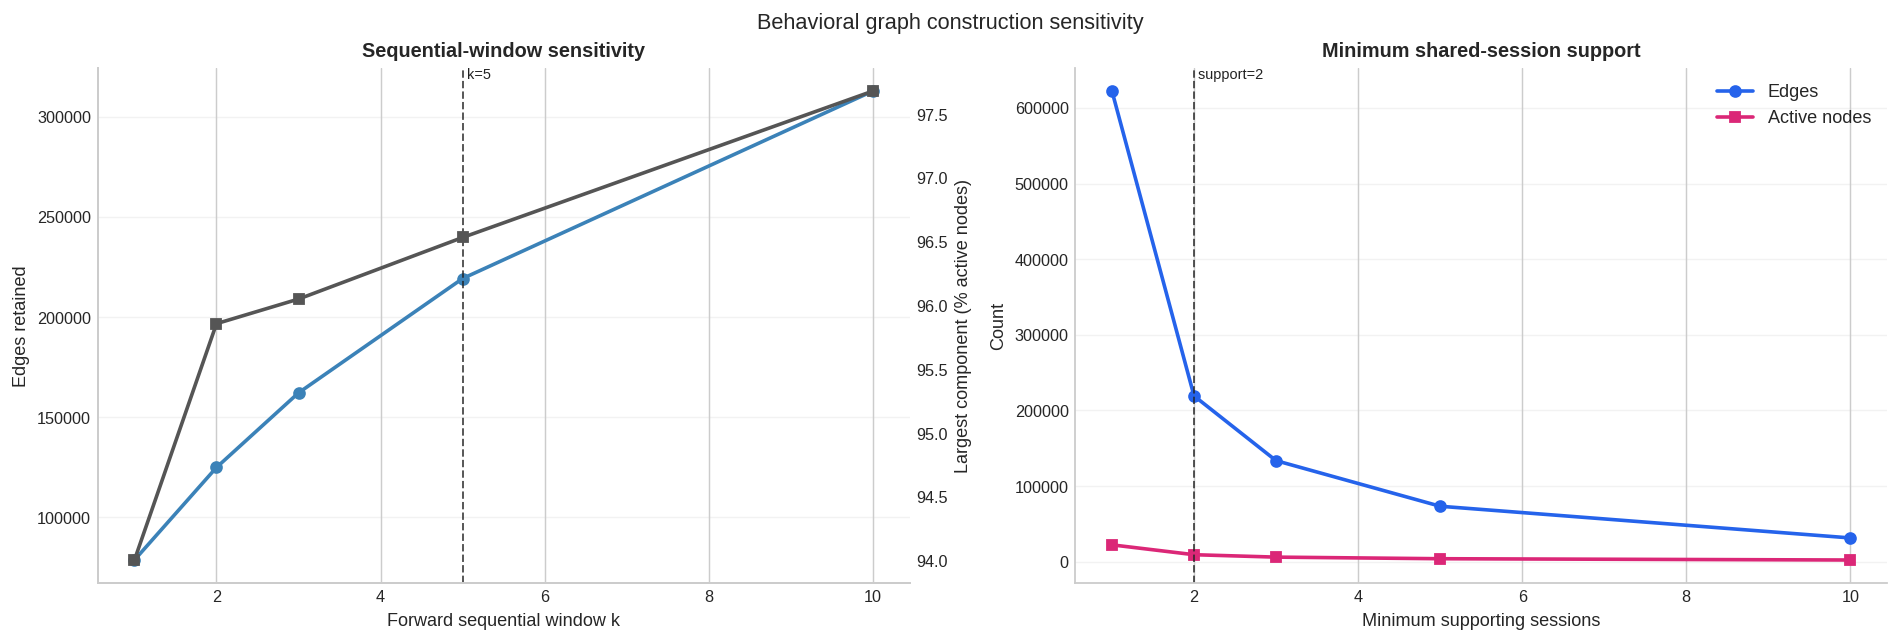

,window_size_scrobbles,candidate_pair_count,raw_unique_edge_count,edge_count,node_count_with_edges,isolated_node_count,largest_component_node_count,largest_component_percentage_of_active_nodes,mean_degree_active_nodes,median_multi_user_decayed_shared_session_cosine
0,1,1671012,256915,78791.0,7456.0,15140.0,7009.0,94.004828,21.134925,0.010469
2,2,3263322,378561,124975.0,8208.0,14388.0,7868.0,95.857700,30.451998,0.010403
3,3,4782755,475289,162185.0,8685.0,13911.0,8342.0,96.050662,37.348302,0.009969
4,5,7621611,622191,219206.0,9202.0,13394.0,8883.0,96.533362,47.643121,0.009114
1,10,13731296,865535,312712.0,9831.0,12765.0,9603.0,97.680806,63.617536,0.007734


In [5]:
if not behavior_window.empty and not behavior_support.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.6), constrained_layout=True)

    line_with_points(
        axes[0],
        behavior_window,
        "window_size_scrobbles",
        "edge_count",
        PALETTE["Behavioral"],
        label="Edges retained at support >= 2",
    )
    axes[0].set_title("Sequential-window sensitivity")
    axes[0].set_xlabel("Forward sequential window k")
    axes[0].set_ylabel("Edges retained")
    selected_vline(axes[0], FROZEN["behavioral_window_size"], "k")
    format_count_axis(axes[0])

    ax0b = axes[0].twinx()
    line_with_points(
        ax0b,
        behavior_window,
        "window_size_scrobbles",
        "largest_component_percentage_of_active_nodes",
        "#555555",
        label="Largest component (%)",
        marker="s",
    )
    ax0b.set_ylabel("Largest component (% active nodes)")
    ax0b.grid(False)

    line_with_points(
        axes[1],
        behavior_support,
        "min_shared_sessions",
        "edge_count",
        "#2563EB",
        label="Edges",
    )
    line_with_points(
        axes[1],
        behavior_support,
        "min_shared_sessions",
        "node_count_with_edges",
        "#DB2777",
        label="Active nodes",
        marker="s",
    )
    selected_vline(axes[1], FROZEN["minimum_shared_sessions"], "support")
    axes[1].set_title("Minimum shared-session support")
    axes[1].set_xlabel("Minimum supporting sessions")
    axes[1].set_ylabel("Count")
    axes[1].legend(loc="upper right")
    format_count_axis(axes[1])

    fig.suptitle("Behavioral graph construction sensitivity", y=1.04)
    savefig(fig, "fig_02_behavioral_graph_construction_sensitivity.png")
    plt.show()

    display(behavior_window)
else:
    display(Markdown("Behavioral construction sensitivity tables are incomplete."))

Saved: reports/figures/sensitivity_freeze_overview/fig_03_acoustic_graph_knn_threshold_sensitivity.png


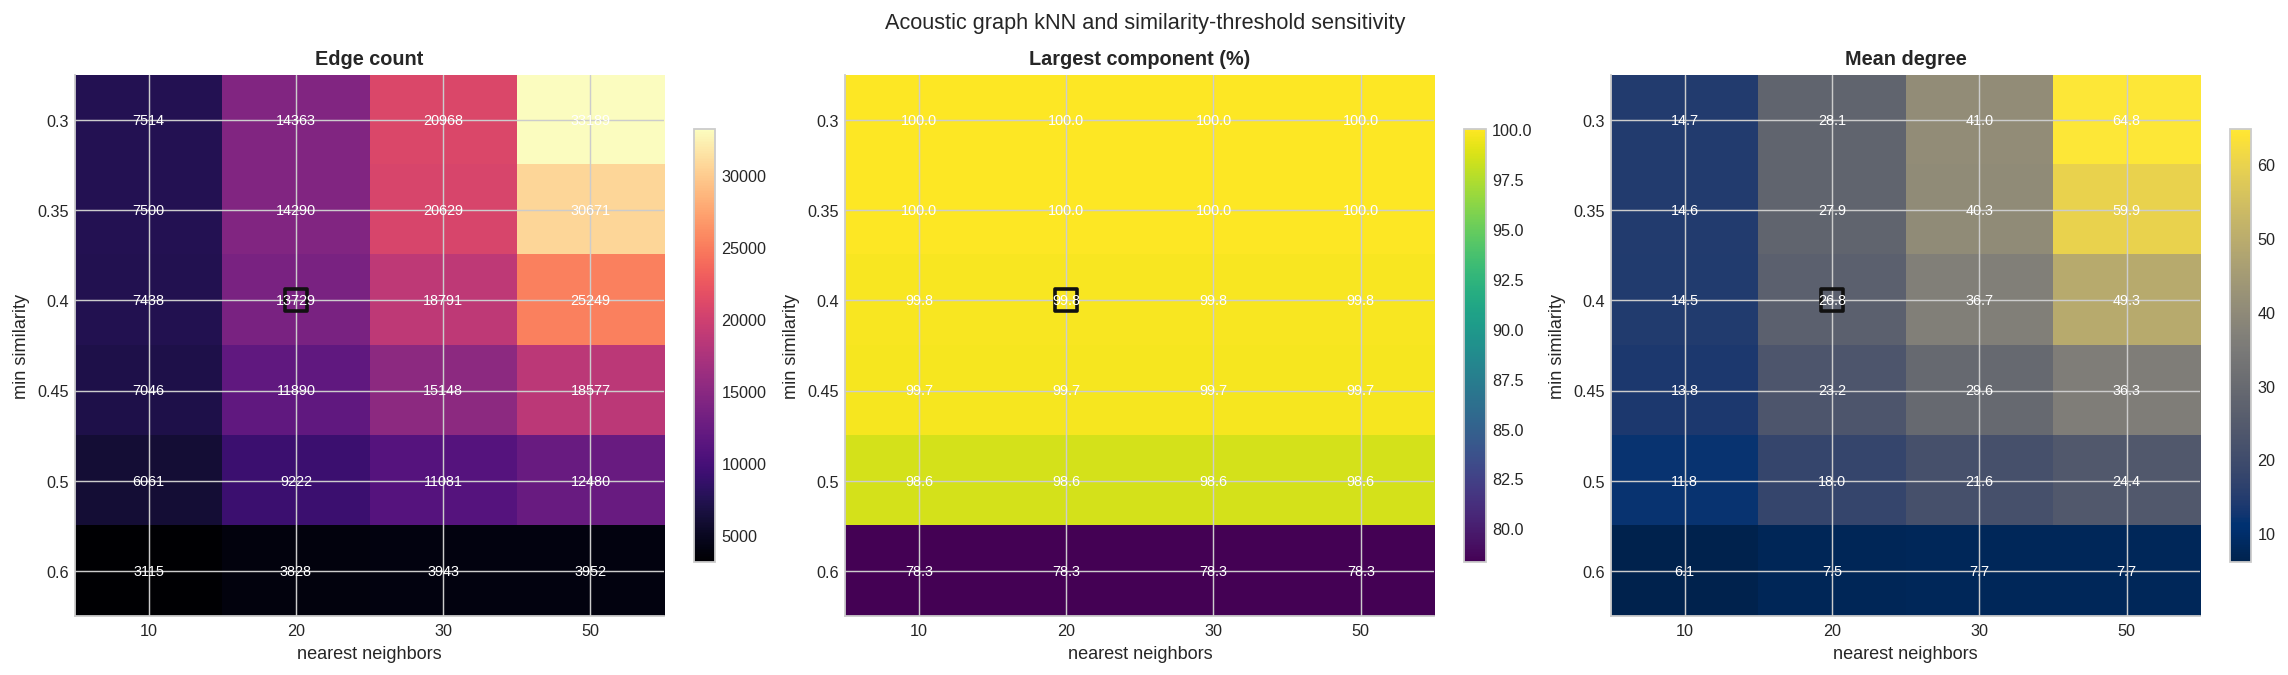

In [6]:
if not acoustic_sensitivity.empty:
    fig, axes = plt.subplots(1, 3, figsize=(17.5, 4.8), constrained_layout=True)

    specs = [
        ("edge_count", "Edge count", "magma", ".0f"),
        ("largest_component_percentage", "Largest component (%)", "viridis", ".1f"),
        ("mean_degree", "Mean degree", "cividis", ".1f"),
    ]
    for ax, (metric, title, cmap, fmt) in zip(axes, specs):
        im, pivot = heatmap(
            ax,
            acoustic_sensitivity,
            row="min_similarity",
            col="nearest_neighbors",
            value=metric,
            title=title,
            cmap=cmap,
            fmt=fmt,
        )
        mark_heatmap_choice(
            ax,
            pivot,
            selected_row=FROZEN["acoustic_min_similarity"],
            selected_col=FROZEN["acoustic_nearest_neighbors"],
        )
        fig.colorbar(im, ax=ax, shrink=0.8)

    fig.suptitle("Acoustic graph kNN and similarity-threshold sensitivity", y=1.05)
    savefig(fig, "fig_03_acoustic_graph_knn_threshold_sensitivity.png")
    plt.show()
else:
    display(Markdown("Acoustic graph sensitivity table is missing."))

## 2. Community Detection and Representation-Learning Sensitivity

These panels summarize the parameters frozen for Louvain/Leiden, Node2Vec, and GAE before the final uniform comparison and genre-inference benchmark.

In [7]:
def load_baseline_runs(rel_path, graph):
    df = read_csv(rel_path)
    if df.empty:
        return df
    df = df.copy()
    df.insert(0, "graph", graph)
    return df

modularity_runs = pd.concat(
    [
        load_baseline_runs("results/behavioral_baselines_balanced_grid/behavioral_baseline_runs.csv", "Behavioral"),
        load_baseline_runs("results/acoustic_baselines_balanced_grid/behavioral_baseline_runs.csv", "Acoustic"),
    ],
    ignore_index=True,
)

if not modularity_runs.empty:
    modularity_summary = (
        modularity_runs
        .groupby(["graph", "algorithm", "resolution"], as_index=False)
        .agg(
            ami_mean=("ami", "mean"),
            ami_std=("ami", "std"),
            nmi_mean=("nmi", "mean"),
            ari_mean=("ari", "mean"),
            modularity_mean=("modularity", "mean"),
            community_count_mean=("community_count", "mean"),
            median_community_size_mean=("median_community_size", "mean"),
        )
    )
    display(modularity_summary.head())
else:
    modularity_summary = pd.DataFrame()

,graph,algorithm,resolution,ami_mean,ami_std,nmi_mean,ari_mean,modularity_mean,community_count_mean,median_community_size_mean
0,Acoustic,Leiden,0.50,0.022895,0.006705,0.108889,-0.001389,0.703141,3.2,395.2
1,Acoustic,Leiden,0.75,0.041158,0.004819,0.177302,0.003932,0.637079,5.6,182.2
2,Acoustic,Leiden,1.00,0.045619,0.002799,0.199680,0.008012,0.588809,6.8,158.1
3,Acoustic,Leiden,1.25,0.049321,0.002529,0.220513,0.014137,0.548521,8.2,127.7
4,Acoustic,Leiden,1.50,0.049613,0.005202,0.243130,0.016691,0.513905,10.2,98.8


Saved: reports/figures/sensitivity_freeze_overview/fig_04_louvain_leiden_resolution_sensitivity.png


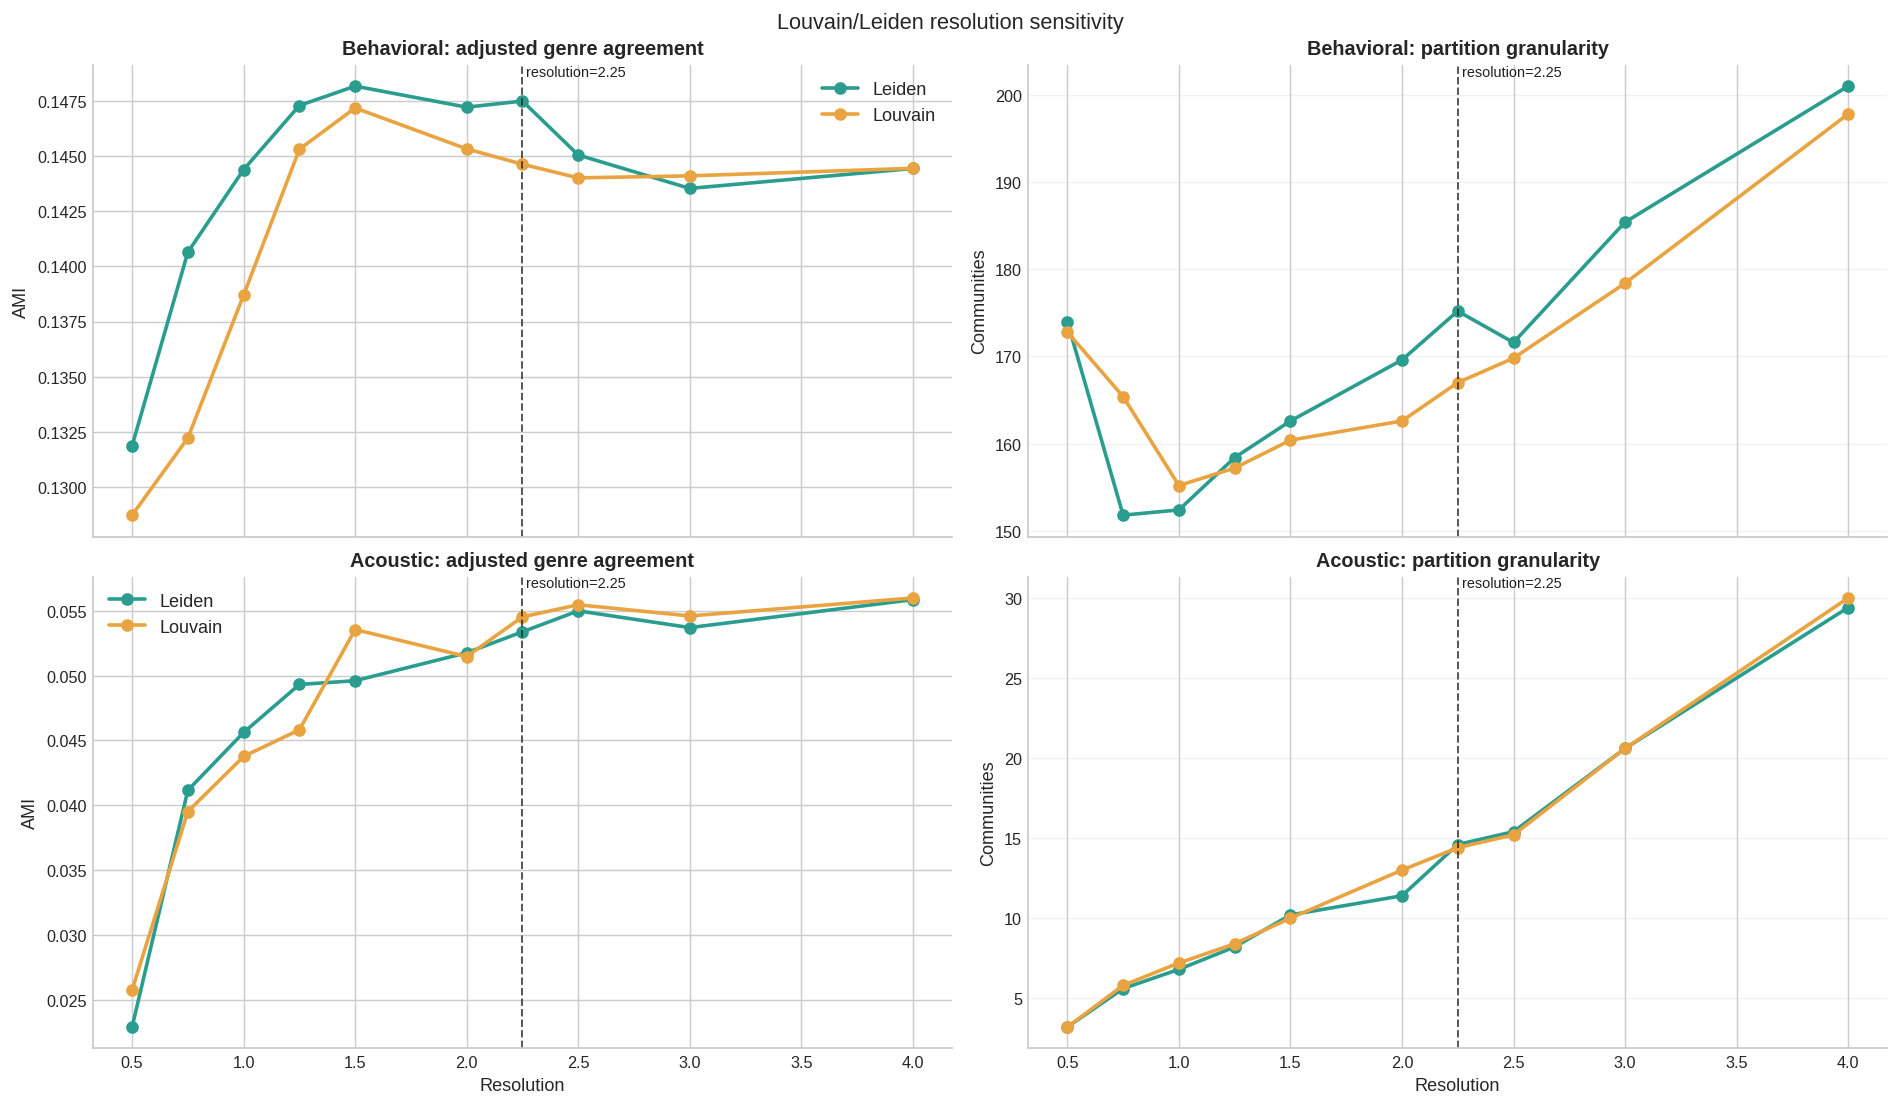

In [8]:
if not modularity_summary.empty:
    fig, axes = plt.subplots(2, 2, figsize=(14.5, 8.2), constrained_layout=True, sharex=True)

    for row_idx, graph in enumerate(["Behavioral", "Acoustic"]):
        graph_df = modularity_summary.loc[modularity_summary["graph"].eq(graph)]
        for algorithm in ["Leiden", "Louvain"]:
            alg_df = graph_df.loc[graph_df["algorithm"].eq(algorithm)]
            color = PALETTE.get(algorithm, None)
            line_with_points(axes[row_idx, 0], alg_df, "resolution", "ami_mean", color, label=algorithm)
            line_with_points(axes[row_idx, 1], alg_df, "resolution", "community_count_mean", color, label=algorithm)

        axes[row_idx, 0].set_title(f"{graph}: adjusted genre agreement")
        axes[row_idx, 0].set_ylabel("AMI")
        selected_vline(axes[row_idx, 0], FROZEN["modularity_resolution"], "resolution")
        axes[row_idx, 0].legend(loc="best")

        axes[row_idx, 1].set_title(f"{graph}: partition granularity")
        axes[row_idx, 1].set_ylabel("Communities")
        selected_vline(axes[row_idx, 1], FROZEN["modularity_resolution"], "resolution")
        format_count_axis(axes[row_idx, 1])

    axes[1, 0].set_xlabel("Resolution")
    axes[1, 1].set_xlabel("Resolution")
    fig.suptitle("Louvain/Leiden resolution sensitivity", y=1.02)
    savefig(fig, "fig_04_louvain_leiden_resolution_sensitivity.png")
    plt.show()
else:
    display(Markdown("Modularity baseline runs are missing."))

In [9]:
def load_node2vec_summary(prefix, graph):
    pq = read_csv(f"{prefix}/node2vec_balanced_pq_summary.csv")
    ks = read_csv(f"{prefix}/node2vec_cluster_k_sensitivity.csv")
    if not pq.empty:
        pq.insert(0, "graph", graph)
    if not ks.empty:
        ks.insert(0, "graph", graph)
    return pq, ks

n2v_behavior_pq, n2v_behavior_k = load_node2vec_summary("results/selection_evidence", "Behavioral")
n2v_acoustic_pq, n2v_acoustic_k = load_node2vec_summary("results/selection_evidence/acoustic_node2vec", "Acoustic")
node2vec_pq = pd.concat([n2v_behavior_pq, n2v_acoustic_pq], ignore_index=True)
node2vec_k = pd.concat([n2v_behavior_k, n2v_acoustic_k], ignore_index=True)

print("Node2Vec p/q rows:", len(node2vec_pq))
print("Node2Vec k rows:", len(node2vec_k))

Node2Vec p/q rows: 18
Node2Vec k rows: 12


Saved: reports/figures/sensitivity_freeze_overview/fig_05_node2vec_pq_sensitivity.png


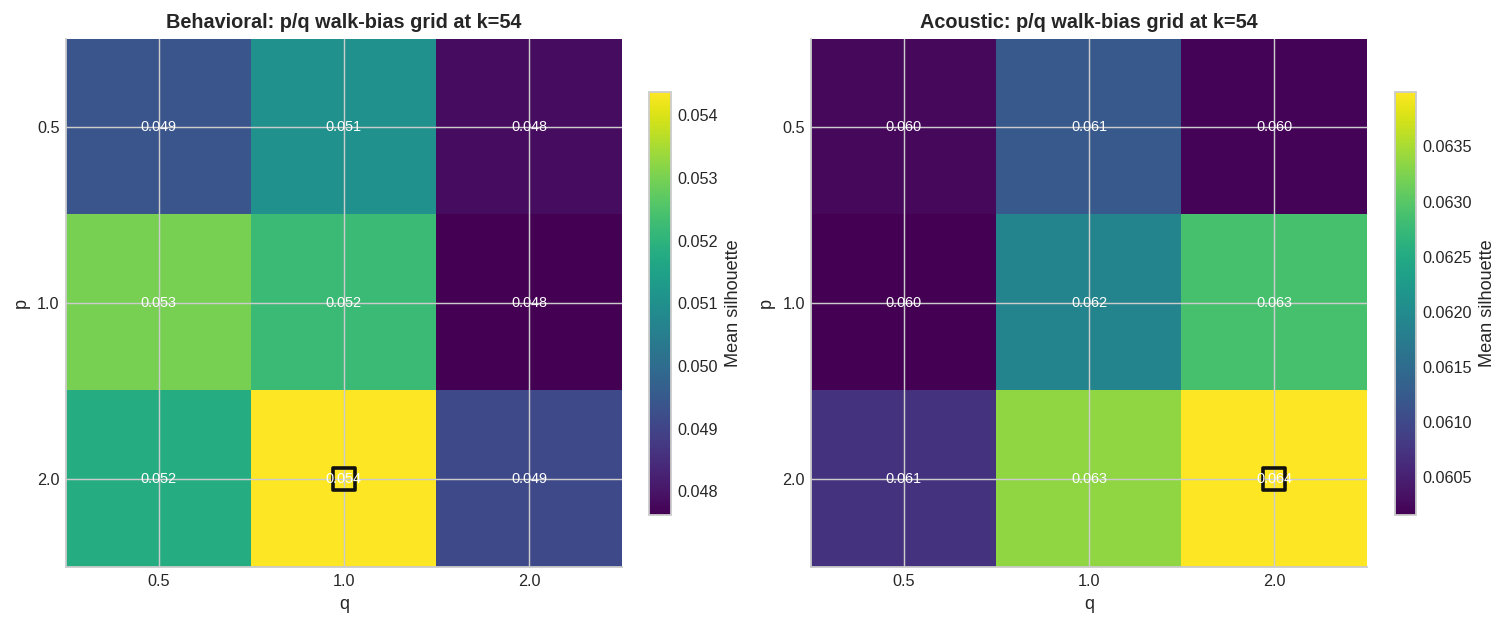

In [10]:
if not node2vec_pq.empty:
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.7), constrained_layout=True)
    for ax, graph in zip(axes, ["Behavioral", "Acoustic"]):
        graph_df = node2vec_pq.loc[node2vec_pq["graph"].eq(graph)]
        im, pivot = heatmap(
            ax,
            graph_df,
            row="p",
            col="q",
            value="silhouette_mean",
            title=f"{graph}: p/q walk-bias grid at k=54",
            cmap="mako" if False else "viridis",
            fmt=".3f",
        )
        selected = FROZEN["node2vec_behavioral"] if graph == "Behavioral" else FROZEN["node2vec_acoustic"]
        mark_heatmap_choice(ax, pivot, selected_row=selected["p"], selected_col=selected["q"])
        fig.colorbar(im, ax=ax, shrink=0.8, label="Mean silhouette")
    savefig(fig, "fig_05_node2vec_pq_sensitivity.png")
    plt.show()
else:
    display(Markdown("Node2Vec p/q summaries are missing."))

Saved: reports/figures/sensitivity_freeze_overview/fig_06_node2vec_k_sensitivity.png


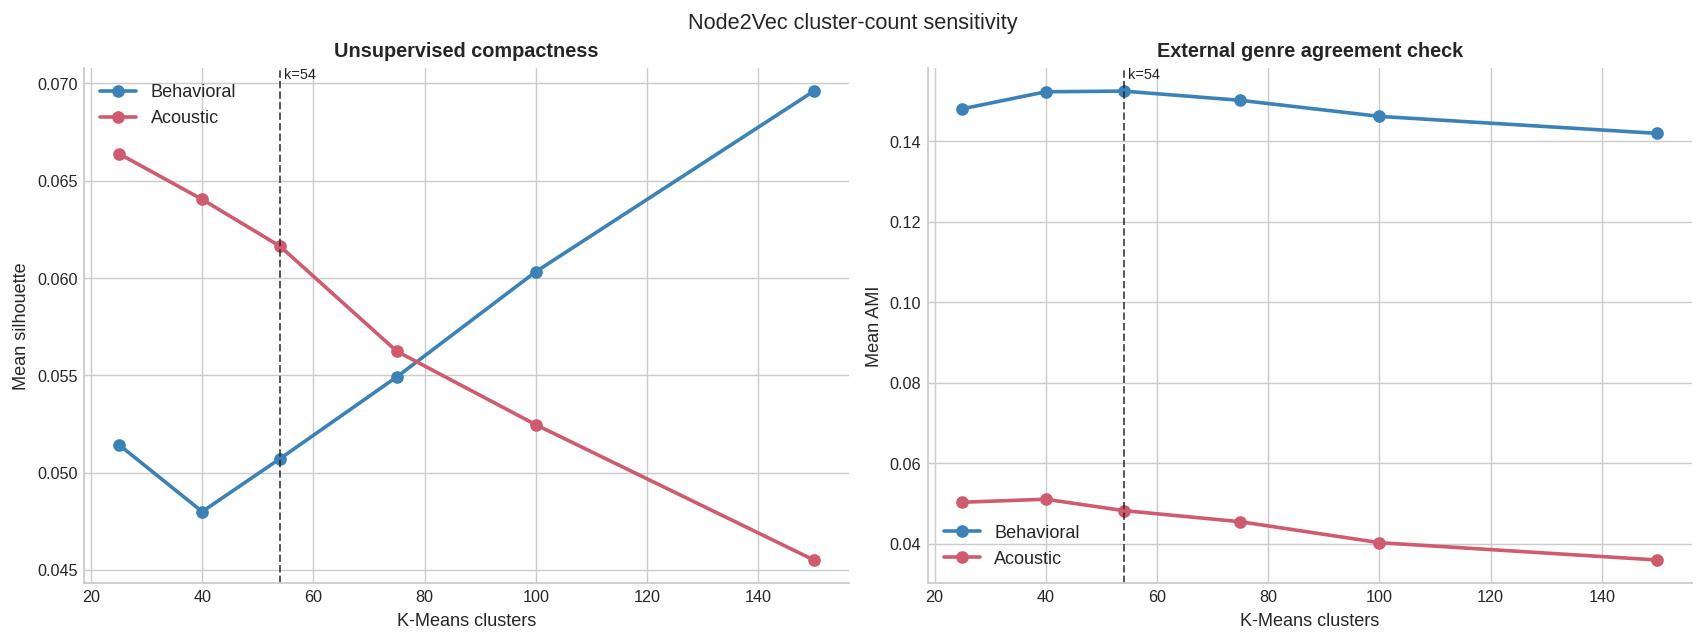

In [11]:
if not node2vec_k.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.6), constrained_layout=True)
    for graph, color in [("Behavioral", PALETTE["Behavioral"]), ("Acoustic", PALETTE["Acoustic"] )]:
        graph_df = node2vec_k.loc[node2vec_k["graph"].eq(graph)].sort_values("k")
        line_with_points(axes[0], graph_df, "k", "silhouette_mean", color, label=graph)
        line_with_points(axes[1], graph_df, "k", "ami_mean", color, label=graph)

    for ax, ylabel, title in [
        (axes[0], "Mean silhouette", "Unsupervised compactness"),
        (axes[1], "Mean AMI", "External genre agreement check"),
    ]:
        selected_vline(ax, FROZEN["kmeans_k"], "k")
        ax.set_xlabel("K-Means clusters")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend(loc="best")

    fig.suptitle("Node2Vec cluster-count sensitivity", y=1.04)
    savefig(fig, "fig_06_node2vec_k_sensitivity.png")
    plt.show()
else:
    display(Markdown("Node2Vec k-sensitivity summaries are missing."))

In [12]:
def load_gae(prefix, graph):
    hyper = read_csv(f"{prefix}/graph_autoencoder_hyperparameter_summary.csv")
    ks = read_csv(f"{prefix}/graph_autoencoder_k_sensitivity.csv")
    if not hyper.empty:
        hyper.insert(0, "graph", graph)
        hyper["combo"] = (
            "z=" + hyper["latent_dim"].astype(str)
            + ", do=" + hyper["dropout"].astype(str)
            + ", lr=" + hyper["learning_rate"].astype(str)
        )
    if not ks.empty:
        ks.insert(0, "graph", graph)
    return hyper, ks

gae_behavior_h, gae_behavior_k = load_gae(
    "results/graph_autoencoder_final_candidates_no_leakage_summary",
    "Behavioral",
)
gae_acoustic_h, gae_acoustic_k = load_gae(
    "results/acoustic_graph_autoencoder_final_candidates_summary",
    "Acoustic",
)
gae_hyper = pd.concat([gae_behavior_h, gae_acoustic_h], ignore_index=True)
gae_k = pd.concat([gae_behavior_k, gae_acoustic_k], ignore_index=True)

if not gae_hyper.empty:
    top_gae = (
        gae_hyper
        .sort_values(["graph", "validation_auc_mean"], ascending=[True, False])
        .groupby("graph", as_index=False)
        .head(4)
    )
    display(top_gae[["graph", "combo", "validation_auc_mean", "validation_average_precision_mean", "silhouette_mean", "ami_mean"]])

,graph,combo,validation_auc_mean,validation_average_precision_mean,silhouette_mean,ami_mean
8,Acoustic,"z=32, do=0.3, lr=0.005",0.827569,0.820320,0.261533,0.038785
9,Acoustic,"z=32, do=0.1, lr=0.005",0.827312,0.821542,0.260755,0.040668
10,Acoustic,"z=16, do=0.1, lr=0.005",0.827188,0.820700,0.263216,0.040335
11,Acoustic,"z=32, do=0.1, lr=0.001",0.826099,0.819470,0.243988,0.042643
0,Behavioral,"z=16, do=0.3, lr=0.005",0.899274,0.892936,0.252299,0.080900
1,Behavioral,"z=32, do=0.3, lr=0.005",0.899192,0.894207,0.243208,0.080871
2,Behavioral,"z=32, do=0.1, lr=0.005",0.896029,0.889526,0.253778,0.079982
3,Behavioral,"z=32, do=0.3, lr=0.001",0.895829,0.887206,0.235662,0.083572


Saved: reports/figures/sensitivity_freeze_overview/fig_07_gae_hyperparameter_sensitivity.png


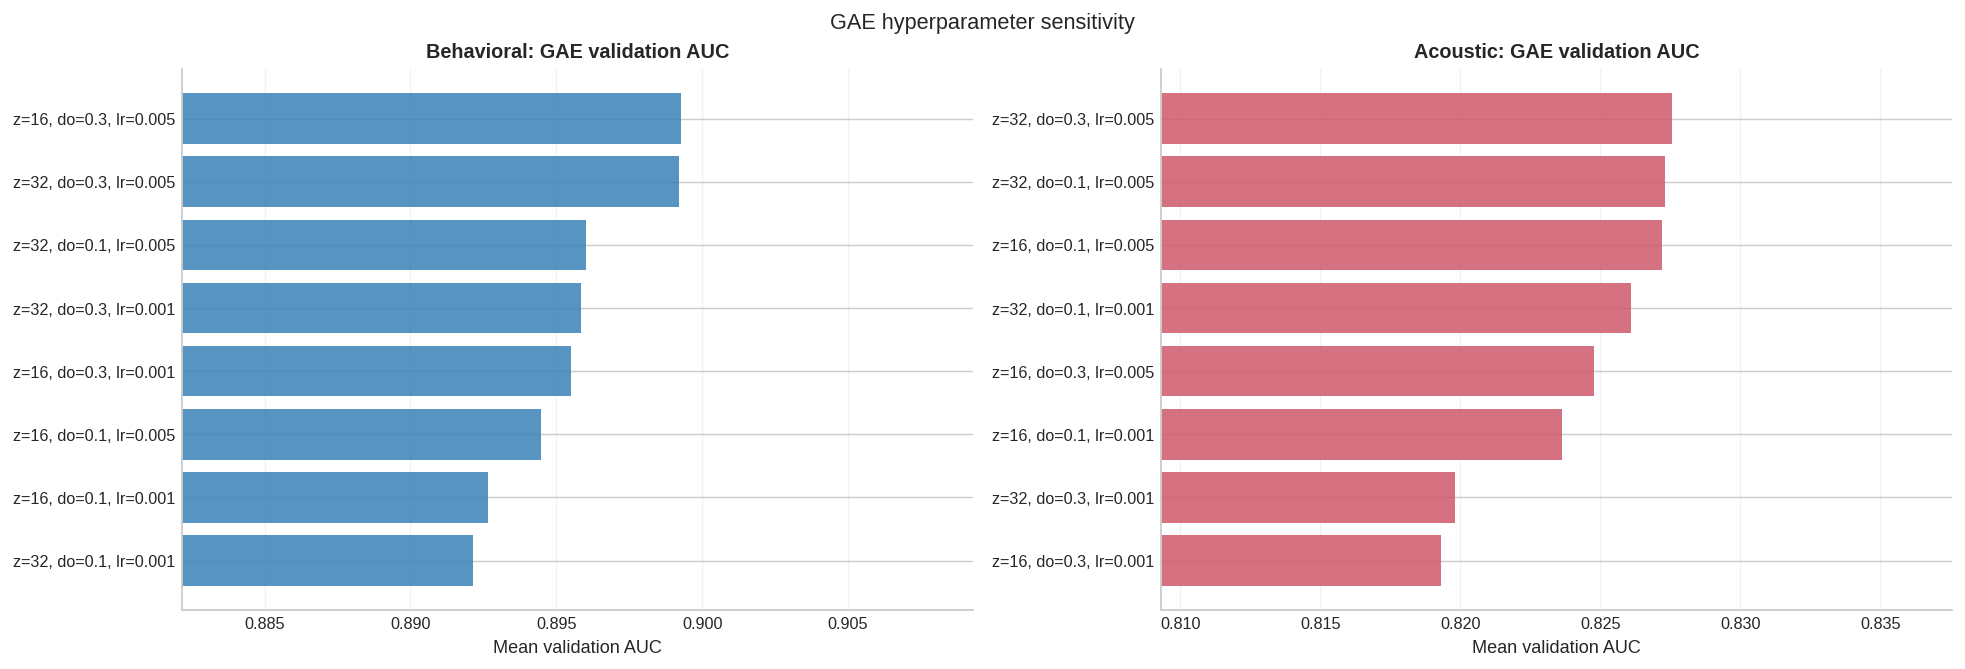

In [13]:
if not gae_hyper.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15.0, 4.8), constrained_layout=True)

    for ax, graph in zip(axes, ["Behavioral", "Acoustic"]):
        graph_df = (
            gae_hyper.loc[gae_hyper["graph"].eq(graph)]
            .sort_values("validation_auc_mean", ascending=True)
            .tail(8)
        )
        colors = [PALETTE[graph]] * len(graph_df)
        ax.barh(graph_df["combo"], graph_df["validation_auc_mean"], color=colors, alpha=0.86)
        ax.set_title(f"{graph}: GAE validation AUC")
        ax.set_xlabel("Mean validation AUC")
        ax.set_xlim(max(0.0, graph_df["validation_auc_mean"].min() - 0.01), min(1.0, graph_df["validation_auc_mean"].max() + 0.01))
        ax.grid(axis="x", alpha=0.25)

    fig.suptitle("GAE hyperparameter sensitivity", y=1.04)
    savefig(fig, "fig_07_gae_hyperparameter_sensitivity.png")
    plt.show()
else:
    display(Markdown("GAE hyperparameter summaries are missing."))

Saved: reports/figures/sensitivity_freeze_overview/fig_08_gae_k_sensitivity.png


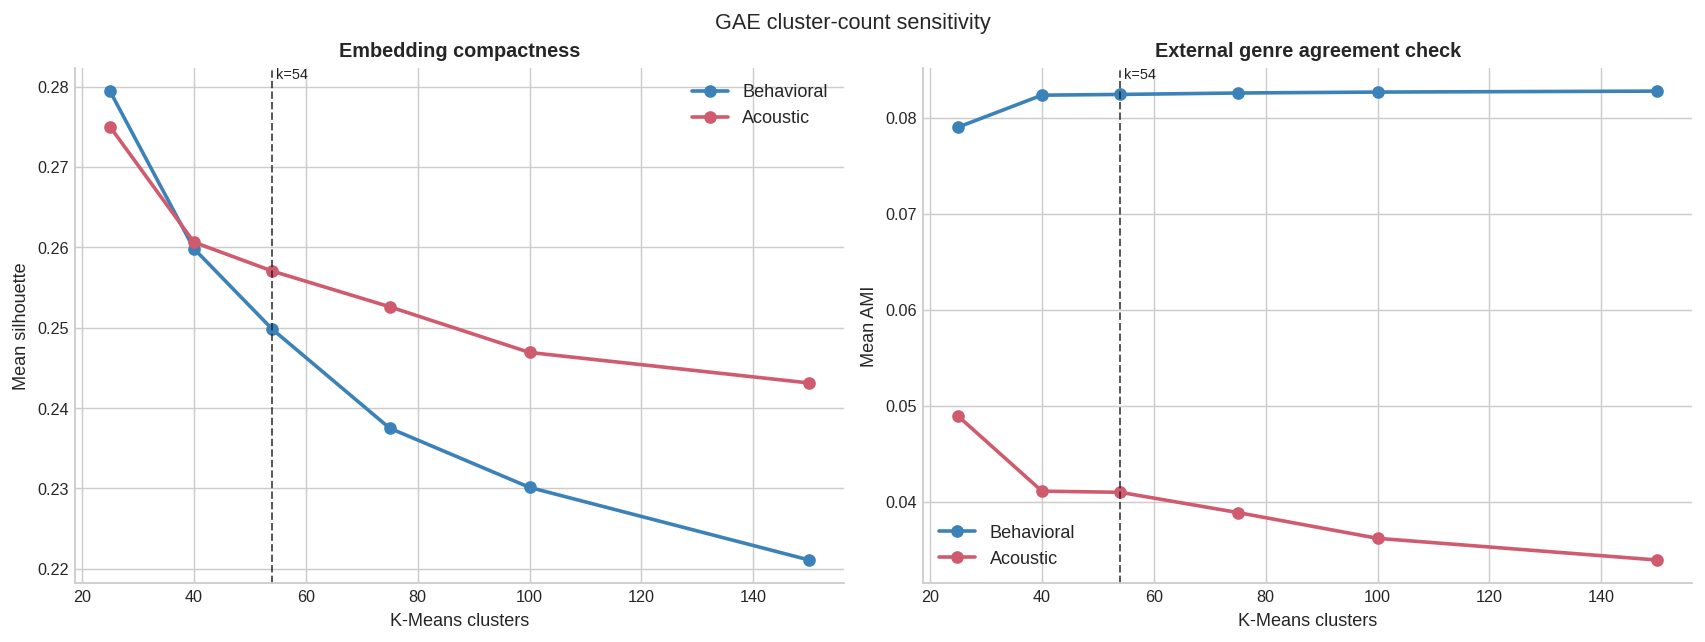

In [14]:
if not gae_k.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.6), constrained_layout=True)
    for graph, color in [("Behavioral", PALETTE["Behavioral"]), ("Acoustic", PALETTE["Acoustic"] )]:
        graph_df = gae_k.loc[gae_k["graph"].eq(graph)].sort_values("k")
        line_with_points(axes[0], graph_df, "k", "silhouette_mean", color, label=graph)
        line_with_points(axes[1], graph_df, "k", "ami_mean", color, label=graph)

    for ax, ylabel, title in [
        (axes[0], "Mean silhouette", "Embedding compactness"),
        (axes[1], "Mean AMI", "External genre agreement check"),
    ]:
        selected_vline(ax, FROZEN["kmeans_k"], "k")
        ax.set_xlabel("K-Means clusters")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend(loc="best")

    fig.suptitle("GAE cluster-count sensitivity", y=1.04)
    savefig(fig, "fig_08_gae_k_sensitivity.png")
    plt.show()
else:
    display(Markdown("GAE k-sensitivity summaries are missing."))

## 3. Genre-Inference Sensitivity

The classifier benchmark uses the frozen representations as inputs. The Logistic Regression regularization parameter is selected inside the repeated cross-validation procedure. The pipeline currently stores the selected value per fold rather than the full inner-C trajectory, so the compact sensitivity view below shows how often each value of $C$ was chosen and how that relates to outer-fold performance.

In [15]:
genre_summary = read_csv("results/genre_inference_benchmark/classification_cv_summary.csv")
genre_folds = read_csv("results/genre_inference_benchmark/classification_cv_fold_metrics.csv")

if not genre_summary.empty:
    genre_summary = genre_summary.sort_values("macro_f1_mean", ascending=False).reset_index(drop=True)
    genre_summary["graph_view"] = genre_summary["family_display_name"].map(method_graph_family)
    display(
        genre_summary[[
            "family_display_name",
            "graph_view",
            "evaluated_node_count",
            "retained_genre_count",
            "selected_regularization_c_median",
            "macro_f1_mean",
            "macro_f1_std",
            "balanced_accuracy_mean",
            "top_k_accuracy_mean",
        ]]
    )

,family_display_name,graph_view,evaluated_node_count,retained_genre_count,selected_regularization_c_median,macro_f1_mean,macro_f1_std,balanced_accuracy_mean,top_k_accuracy_mean
0,Node2Vec behavioral,Behavioral,3101.0,109.0,0.1,0.099161,0.003260,0.129711,0.255556
1,Node2Vec acoustic,Acoustic,567.0,33.0,0.1,0.069160,0.009668,0.074933,0.279365
2,GAE acoustic,Acoustic,567.0,33.0,100.0,0.044598,0.006686,0.078287,0.148360
3,GAE behavioral,Behavioral,3101.0,109.0,100.0,0.039110,0.003273,0.068658,0.111216
4,Acoustic smooth2,Acoustic,567.0,33.0,10.0,0.023012,0.003405,0.043742,0.088536
5,Acoustic smooth1,Acoustic,567.0,33.0,100.0,0.016554,0.005197,0.037565,0.065961
6,Acoustic raw,Acoustic,567.0,33.0,10.0,0.012401,0.003167,0.039938,0.075485
7,Behavioral smooth2,Behavioral,3101.0,109.0,100.0,0.006655,0.000877,0.019069,0.060045
8,Behavioral smooth1,Behavioral,3101.0,109.0,100.0,0.005961,0.000776,0.016305,0.053918
9,Behavioral raw,Behavioral,3101.0,109.0,100.0,0.004695,0.000491,0.014425,0.040439


Saved: reports/figures/sensitivity_freeze_overview/fig_09_genre_inference_representation_benchmark.png


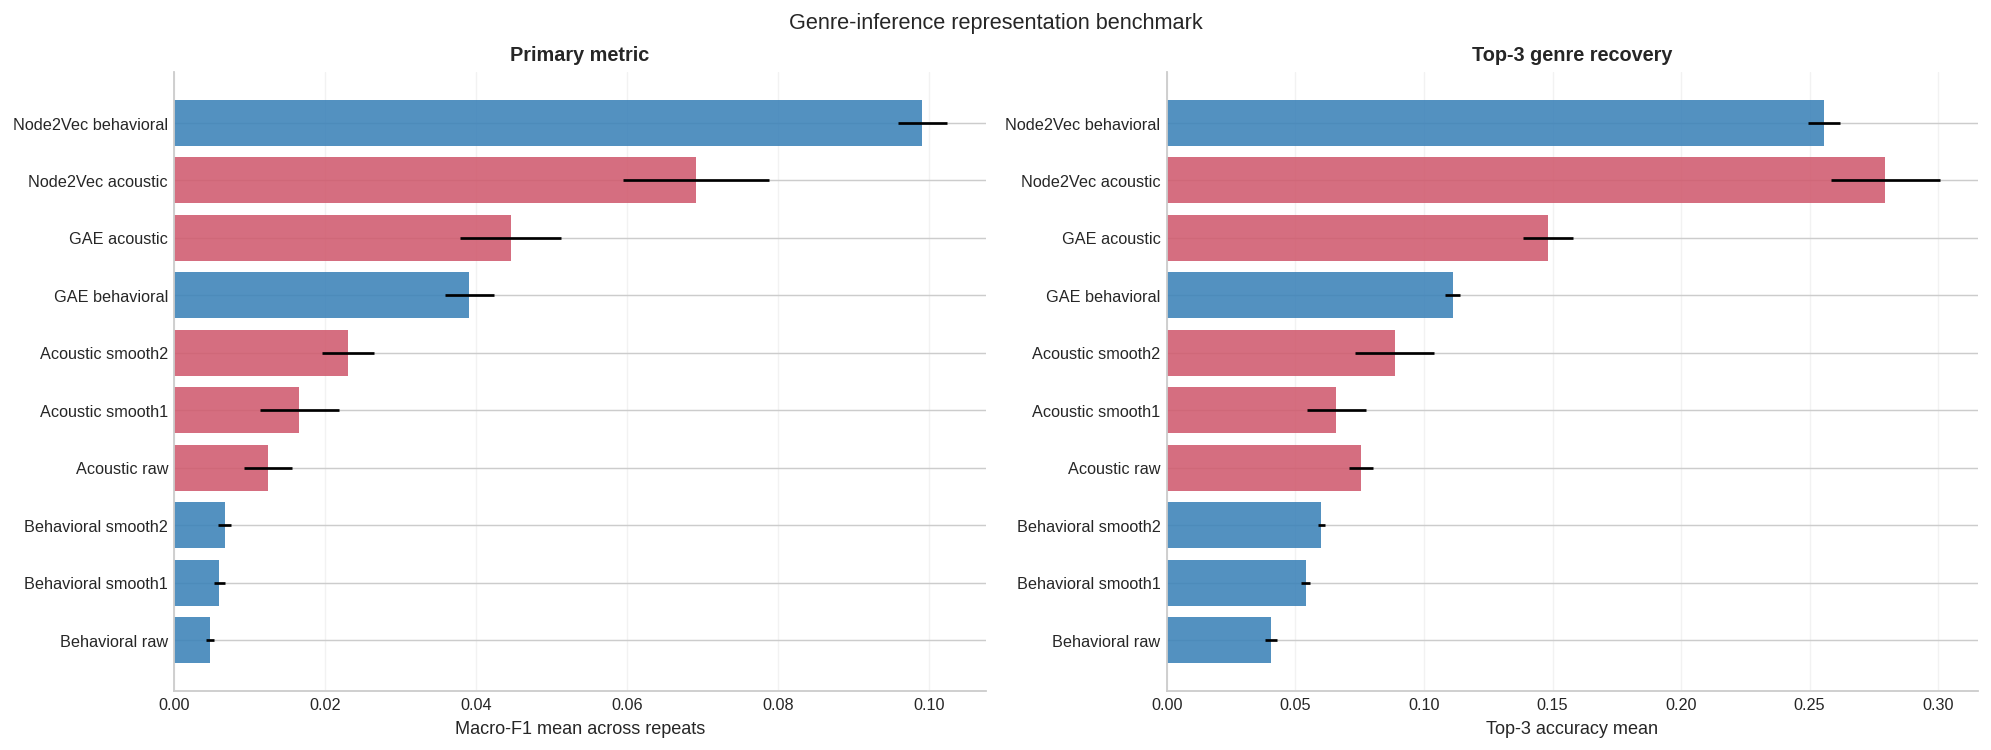

In [16]:
if not genre_summary.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15.2, 5.4), constrained_layout=True)
    plot_df = genre_summary.sort_values("macro_f1_mean", ascending=True).copy()
    colors = [PALETTE[method_graph_family(name)] for name in plot_df["family_display_name"]]

    axes[0].barh(
        plot_df["family_display_name"],
        plot_df["macro_f1_mean"],
        xerr=plot_df["macro_f1_std"],
        color=colors,
        alpha=0.88,
    )
    axes[0].set_title("Primary metric")
    axes[0].set_xlabel("Macro-F1 mean across repeats")
    axes[0].grid(axis="x", alpha=0.25)

    axes[1].barh(
        plot_df["family_display_name"],
        plot_df["top_k_accuracy_mean"],
        xerr=plot_df["top_k_accuracy_std"],
        color=colors,
        alpha=0.88,
    )
    axes[1].set_title("Top-3 genre recovery")
    axes[1].set_xlabel("Top-3 accuracy mean")
    axes[1].grid(axis="x", alpha=0.25)

    fig.suptitle("Genre-inference representation benchmark", y=1.04)
    savefig(fig, "fig_09_genre_inference_representation_benchmark.png")
    plt.show()
else:
    display(Markdown("Genre-inference summary is missing."))

Saved: reports/figures/sensitivity_freeze_overview/fig_10_genre_inference_c_selection_sensitivity.png


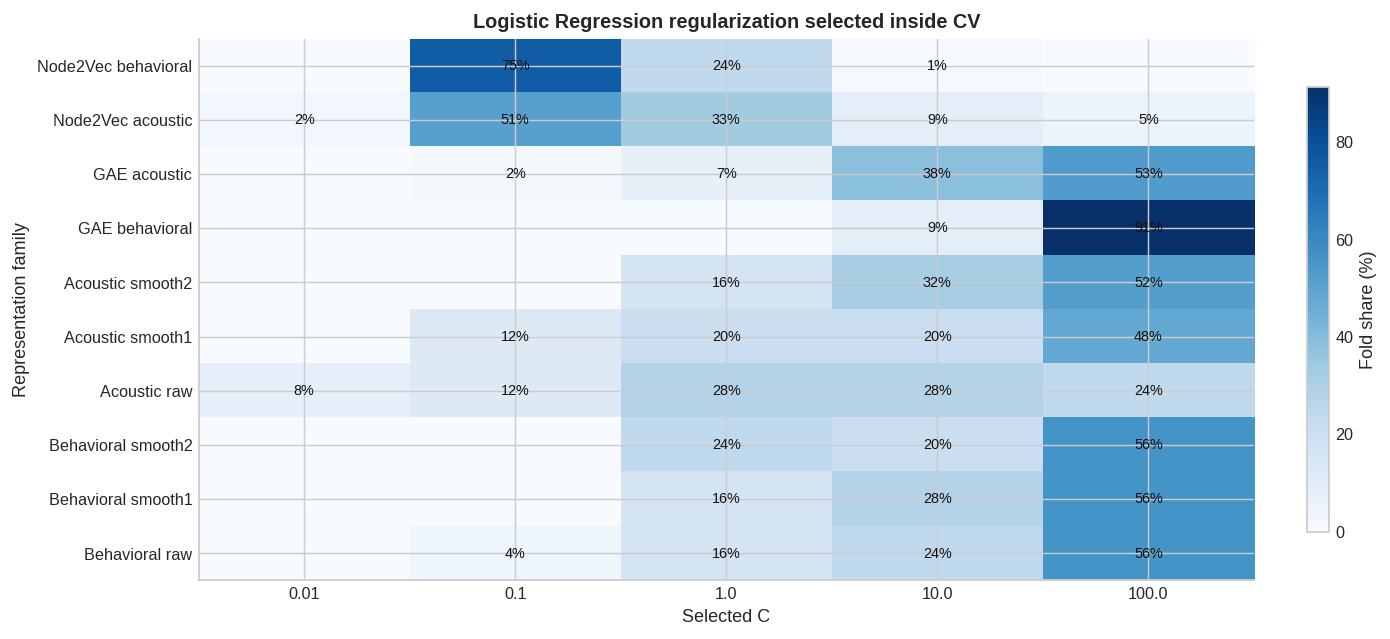

,family_display_name,selected_regularization_c,fold_count,macro_f1_mean,macro_f1_std,balanced_accuracy_mean
0,Acoustic raw,0.01,2,0.016585,0.019559,0.063131
1,Acoustic raw,0.10,3,0.005658,0.003222,0.025253
2,Acoustic raw,1.00,7,0.005246,0.004412,0.027778
3,Acoustic raw,10.00,7,0.015185,0.009443,0.046898
4,Acoustic raw,100.00,6,0.014108,0.013695,0.034741
5,Acoustic smooth1,0.10,3,0.007278,0.006417,0.020202
6,Acoustic smooth1,1.00,5,0.009012,0.005605,0.027273
7,Acoustic smooth1,10.00,5,0.021256,0.013201,0.051010
8,Acoustic smooth1,100.00,12,0.016804,0.009684,0.040109
9,Acoustic smooth2,1.00,4,0.018596,0.008113,0.036616


Saved: reports/tables/table_genre_inference_selected_c_sensitivity.csv


In [17]:
if not genre_folds.empty:
    c_counts = (
        genre_folds
        .groupby(["family_display_name", "selected_regularization_c"], as_index=False)
        .size()
        .rename(columns={"size": "fold_count"})
    )
    c_totals = c_counts.groupby("family_display_name")["fold_count"].transform("sum")
    c_counts["fold_percentage"] = 100 * c_counts["fold_count"] / c_totals

    family_order = genre_summary["family_display_name"].tolist() if not genre_summary.empty else sorted(c_counts["family_display_name"].unique())
    c_order = sorted(c_counts["selected_regularization_c"].unique())
    c_pivot = (
        c_counts
        .pivot_table(index="family_display_name", columns="selected_regularization_c", values="fold_percentage", fill_value=0.0)
        .reindex(index=family_order, columns=c_order, fill_value=0.0)
    )

    fig, ax = plt.subplots(figsize=(10.6, max(4.8, 0.38 * len(c_pivot))), constrained_layout=True)
    im = ax.imshow(c_pivot.to_numpy(), aspect="auto", cmap="Blues", vmin=0, vmax=max(1, c_pivot.to_numpy().max()))
    ax.set_title("Logistic Regression regularization selected inside CV")
    ax.set_xlabel("Selected C")
    ax.set_ylabel("Representation family")
    ax.set_xticks(np.arange(len(c_pivot.columns)))
    ax.set_xticklabels([str(c) for c in c_pivot.columns])
    ax.set_yticks(np.arange(len(c_pivot.index)))
    ax.set_yticklabels(c_pivot.index)
    for i in range(c_pivot.shape[0]):
        for j in range(c_pivot.shape[1]):
            value = c_pivot.iloc[i, j]
            if value > 0:
                ax.text(j, i, f"{value:.0f}%", ha="center", va="center", fontsize=8, color="#111111")
    fig.colorbar(im, ax=ax, shrink=0.82, label="Fold share (%)")
    savefig(fig, "fig_10_genre_inference_c_selection_sensitivity.png")
    plt.show()

    c_perf = (
        genre_folds
        .groupby(["family_display_name", "selected_regularization_c"], as_index=False)
        .agg(
            fold_count=("macro_f1", "size"),
            macro_f1_mean=("macro_f1", "mean"),
            macro_f1_std=("macro_f1", "std"),
            balanced_accuracy_mean=("balanced_accuracy", "mean"),
        )
        .sort_values(["family_display_name", "selected_regularization_c"])
    )
    display(c_perf)
    c_perf.to_csv(TABLES_DIR / "table_genre_inference_selected_c_sensitivity.csv", index=False)
    print("Saved: reports/tables/table_genre_inference_selected_c_sensitivity.csv")
else:
    display(Markdown("Genre-inference fold metrics are missing."))

## 4. Compact Takeaways

Use this cell after running the notebook to capture a compact textual readout for the paper or appendix. It intentionally separates unsupervised freezing criteria from external-label diagnostics.

In [18]:
notes = []

if not behavior_window.empty:
    selected = behavior_window.loc[behavior_window["window_size_scrobbles"].eq(FROZEN["behavioral_window_size"])]
    if not selected.empty:
        r = selected.iloc[0]
        notes.append(
            f"Behavioral graph: sequential k={FROZEN['behavioral_window_size']} with support>={FROZEN['minimum_shared_sessions']} retains {int(r['edge_count']):,} edges and a largest component covering {r['largest_component_percentage_of_active_nodes']:.1f}% of active nodes."
        )

if not acoustic_sensitivity.empty:
    selected = acoustic_sensitivity.loc[
        acoustic_sensitivity["nearest_neighbors"].eq(FROZEN["acoustic_nearest_neighbors"])
        & acoustic_sensitivity["min_similarity"].eq(FROZEN["acoustic_min_similarity"])
    ]
    if not selected.empty:
        r = selected.iloc[0]
        notes.append(
            f"Acoustic graph: kNN={FROZEN['acoustic_nearest_neighbors']} and min similarity={FROZEN['acoustic_min_similarity']:.2f} retains {int(r['edge_count']):,} edges, {int(r['largest_component_node_count']):,} nodes in the largest component, and mean degree {r['mean_degree']:.1f}."
        )

if not node2vec_pq.empty:
    for graph in ["Behavioral", "Acoustic"]:
        graph_df = node2vec_pq.loc[node2vec_pq["graph"].eq(graph)].sort_values("silhouette_mean", ascending=False)
        if not graph_df.empty:
            r = graph_df.iloc[0]
            notes.append(
                f"Node2Vec {graph.lower()}: best p/q by mean silhouette at k=54 is p={r['p']}, q={r['q']} (silhouette={r['silhouette_mean']:.4f})."
            )

if not gae_hyper.empty:
    for graph in ["Behavioral", "Acoustic"]:
        graph_df = gae_hyper.loc[gae_hyper["graph"].eq(graph)].sort_values("validation_auc_mean", ascending=False)
        if not graph_df.empty:
            r = graph_df.iloc[0]
            notes.append(
                f"GAE {graph.lower()}: best validation AUC uses latent={int(r['latent_dim'])}, dropout={r['dropout']}, lr={r['learning_rate']} (AUC={r['validation_auc_mean']:.4f})."
            )

if not genre_summary.empty:
    r = genre_summary.iloc[0]
    notes.append(
        f"Genre inference: the best representation is {r['family_display_name']} with macro-F1={r['macro_f1_mean']:.3f}, balanced accuracy={r['balanced_accuracy_mean']:.3f}, and top-3 accuracy={r['top_k_accuracy_mean']:.3f}."
    )

for note in notes:
    display(Markdown(f"- {note}"))

- Behavioral graph: sequential k=5 with support>=2 retains 219,206 edges and a largest component covering 96.5% of active nodes.

- Acoustic graph: kNN=20 and min similarity=0.40 retains 13,729 edges, 1,022 nodes in the largest component, and mean degree 26.8.

- Node2Vec behavioral: best p/q by mean silhouette at k=54 is p=2.0, q=1.0 (silhouette=0.0544).

- Node2Vec acoustic: best p/q by mean silhouette at k=54 is p=2.0, q=2.0 (silhouette=0.0640).

- GAE behavioral: best validation AUC uses latent=16, dropout=0.3, lr=0.005 (AUC=0.8993).

- GAE acoustic: best validation AUC uses latent=32, dropout=0.3, lr=0.005 (AUC=0.8276).

- Genre inference: the best representation is Node2Vec behavioral with macro-F1=0.099, balanced accuracy=0.130, and top-3 accuracy=0.256.